# 📍 Google Maps Business Analysis Dashboard

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("D:\Google_Maps_Business_Analysis\data\cleaned_business_data.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
C:\Users\AKSHAY KUMAR\AppData\Local\Temp\ipykernel_18536\3559782065.py:1: SyntaxWarning: invalid escape sequence '\G'
  df = pd.read_csv("D:\Google_Maps_Business_Analysis\data\cleaned_business_data.csv")


,Shop Name,Category,Street/Area,City,Phone,Website,Has Website,Rating (fill manually),Reviews (fill manually),Latitude,Longitude
0,Champa Books,Books,-,Bhagalpur,Not Available,No Website,No,4.5,45,25.239651,86.933158
1,Jawaharlal Nehru Medical College Hospital (JNM...,Blood Bank,"Mayaganj, Tilkamanjhi",Bhagalpur,+91 6412409555,https://www.jlnmcbgp.org/,Yes,4.4,50,25.263979,87.002084
2,"Canara Bank, Hussainabad",Bank,"Balti Karkhana Chowk, Bousi Road",Bhagalpur,Not Available,No Website,No,4.3,55,25.231848,86.973340
3,"Reliance Digital, Mirjanhat",Electronics,"Ground Floor & First Floor City Centre, Gurath...",Bhagalpur,+917061603902,No Website,No,4.2,60,25.236897,86.974406
4,"Axis Bank, Mohdinagar",Bank,"Khata No 717, Kh No 66, 1st &, Bausi Road",Bhagalpur,+91 1860 500 5555,No Website,No,4.1,65,25.233058,86.973347


In [8]:
df.shape

(102, 11)

In [9]:
df.columns

Index(['Shop Name', 'Category', 'Street/Area', 'City', 'Phone', 'Website',
       'Has Website', 'Rating (fill manually)', 'Reviews (fill manually)',
       'Latitude', 'Longitude'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Shop Name                102 non-null    object 
 1   Category                 102 non-null    object 
 2   Street/Area              102 non-null    object 
 3   City                     102 non-null    object 
 4   Phone                    102 non-null    object 
 5   Website                  102 non-null    object 
 6   Has Website              102 non-null    object 
 7   Rating (fill manually)   102 non-null    float64
 8   Reviews (fill manually)  102 non-null    int64  
 9   Latitude                 102 non-null    float64
 10  Longitude                102 non-null    float64
dtypes: float64(3), int64(1), object(7)
memory usage: 8.9+ KB


In [11]:
df.isnull().sum()

Shop Name                  0
Category                   0
Street/Area                0
City                       0
Phone                      0
Website                    0
Has Website                0
Rating (fill manually)     0
Reviews (fill manually)    0
Latitude                   0
Longitude                  0
dtype: int64

In [12]:
df.rename(columns={
    "Rating (fill manually)": "Rating",
    "Reviews (fill manually)": "Reviews"
}, inplace=True)

df.head()

,Shop Name,Category,Street/Area,City,Phone,Website,Has Website,Rating,Reviews,Latitude,Longitude
0,Champa Books,Books,-,Bhagalpur,Not Available,No Website,No,4.5,45,25.239651,86.933158
1,Jawaharlal Nehru Medical College Hospital (JNM...,Blood Bank,"Mayaganj, Tilkamanjhi",Bhagalpur,+91 6412409555,https://www.jlnmcbgp.org/,Yes,4.4,50,25.263979,87.002084
2,"Canara Bank, Hussainabad",Bank,"Balti Karkhana Chowk, Bousi Road",Bhagalpur,Not Available,No Website,No,4.3,55,25.231848,86.973340
3,"Reliance Digital, Mirjanhat",Electronics,"Ground Floor & First Floor City Centre, Gurath...",Bhagalpur,+917061603902,No Website,No,4.2,60,25.236897,86.974406
4,"Axis Bank, Mohdinagar",Bank,"Khata No 717, Kh No 66, 1st &, Bausi Road",Bhagalpur,+91 1860 500 5555,No Website,No,4.1,65,25.233058,86.973347


In [13]:
df[["Rating", "Reviews"]].describe()

,Rating,Reviews
count,102.000000,102.000000
mean,3.261765,85.000000
std,0.760021,24.615861
min,1.900000,45.000000
25%,2.625000,65.000000
50%,3.300000,85.000000
75%,3.900000,105.000000
max,4.500000,125.000000


In [14]:
print("Total Businesses:", len(df))

Total Businesses: 102


In [15]:
df["Has Website"].value_counts()

Has Website
No     101
Yes      1
Name: count, dtype: int64

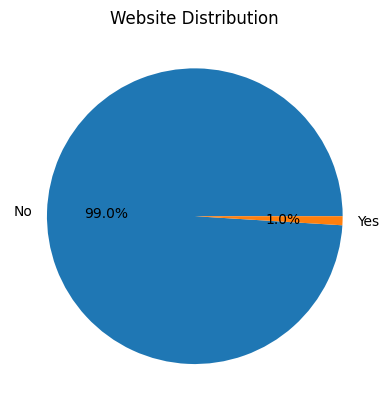

In [16]:
df["Has Website"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Website Distribution")
plt.ylabel("")
plt.show()

In [17]:
df["Category"].value_counts().head(10)

Category
General Shop            16
Kirana/General Store     9
Restaurant               8
Medical Store            7
Department Store         6
Tailor                   5
Mall                     4
Electronics              4
Telecommunication        4
Clothes                  4
Name: count, dtype: int64

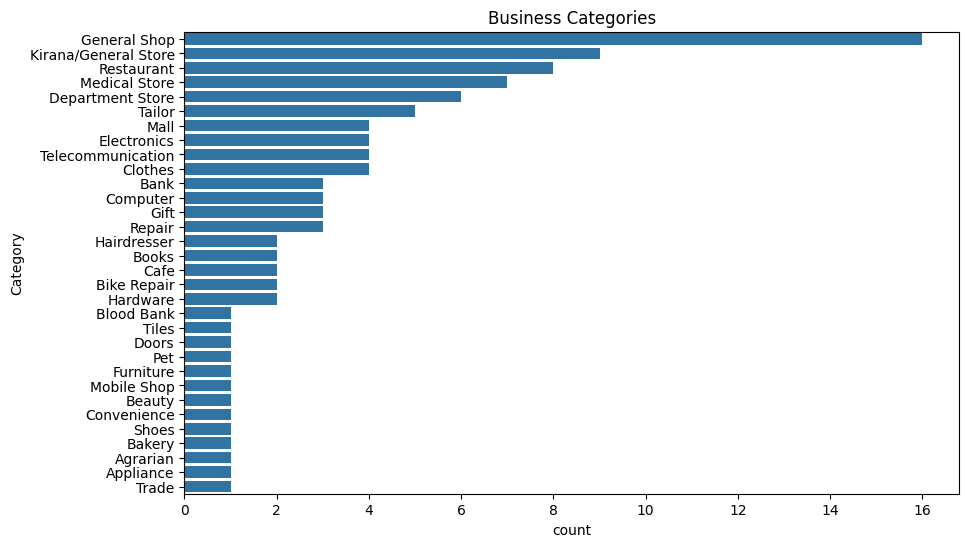

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="Category",
    data=df,
    order=df["Category"].value_counts().index
)

plt.title("Business Categories")
plt.show()

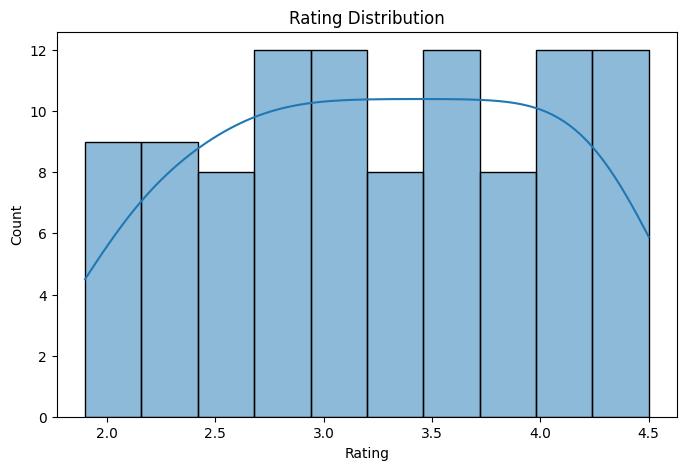

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating"],
    bins=10,
    kde=True
)

plt.title("Rating Distribution")
plt.show()

In [20]:
high = df[
    (df["Has Website"]=="No")
    &
    (df["Rating"]>=4)
]

high[
    [
        "Shop Name",
        "Category",
        "Rating",
        "Reviews"
    ]
]

,Shop Name,Category,Rating,Reviews
0,Champa Books,Books,4.5,45
2,"Canara Bank, Hussainabad",Bank,4.3,55
3,"Reliance Digital, Mirjanhat",Electronics,4.2,60
4,"Axis Bank, Mohdinagar",Bank,4.1,65
5,Sriyash Mall,Mall,4.0,70
27,anu general store,Kirana/General Store,4.5,95
28,Sk trades,Gift,4.4,100
29,Six2nine General store,General Shop,4.3,105
30,Zikra telecome,Telecommunication,4.2,110
31,hira general store,General Shop,4.1,115


In [21]:
top10 = df[
    df["Has Website"]=="No"
].sort_values(
    by=["Rating","Reviews"],
    ascending=False
).head(10)

top10

,Shop Name,Category,Street/Area,City,Phone,Website,Has Website,Rating,Reviews,Latitude,Longitude
81,Smart online cafe,Computer,-,Bhagalpur,Not Available,No Website,No,4.5,110,25.239914,86.940321
27,anu general store,Kirana/General Store,-,Bhagalpur,Not Available,No Website,No,4.5,95,25.245809,86.948657
54,jitendra readymade,General Shop,-,Bhagalpur,Not Available,No Website,No,4.5,60,25.247982,86.948343
0,Champa Books,Books,-,Bhagalpur,Not Available,No Website,No,4.5,45,25.239651,86.933158
82,SHUBHAM Iron mart,Convenience,-,Bhagalpur,Not Available,No Website,No,4.4,115,25.240200,86.941435
28,Sk trades,Gift,-,Bhagalpur,Not Available,No Website,No,4.4,100,25.246337,86.948744
55,rupesh mobile repairing store,Mobile Shop,-,Bhagalpur,Not Available,No Website,No,4.4,65,25.247732,86.946246
83,Student corner nathnagar,Cafe,-,Bhagalpur,Not Available,No Website,No,4.3,120,25.240040,86.941490
29,Six2nine General store,General Shop,-,Bhagalpur,Not Available,No Website,No,4.3,105,25.247408,86.949151
56,sp yadav store,Gift,-,Bhagalpur,Not Available,No Website,No,4.3,70,25.247920,86.946741
